# 02 — Naive Baseline: S-Learner and T-Learner

Before building the debiased neural model, this notebook establishes what
the "obvious" approach gets wrong. An S-learner and T-learner are both
standard, widely-used uplift methods -- and both ignore the confounding
problem from Notebook 01 entirely. They give us a concrete number the
Day 2 model needs to beat, and a concrete failure mode (systematic bias
on exactly the segments that matter for targeting) to point at.

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import lightgbm as lgb

from simulate import simulate_promo_data
from evaluation import pehe

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

df = simulate_promo_data(n=20_000, seed=42)
feature_cols = [
    "loyalty_tier", "price_sensitivity", "lead_time_days",
    "past_bookings", "device_mobile", "length_of_stay", "base_price",
]

train_df, test_df = train_test_split(df, test_size=0.3, random_state=0)
print(f"train: {len(train_df)}, test: {len(test_df)}")

train: 14000, test: 6000


## S-learner

A single model trained on `[features, treatment] -> outcome`. CATE is
estimated by scoring each test unit twice (once with `treatment=1`, once
with `treatment=0`) and taking the difference. Simple, but known to suffer
from **regularization bias**: if the model doesn't strongly need the
treatment feature to fit the outcome well, it gets down-weighted and the
estimated effect shrinks toward zero -- exactly what we'd expect to see
here given how noisy the treatment signal is relative to the covariates.

In [2]:
s_features = feature_cols + ["treatment"]

s_model = lgb.LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, verbose=-1)
s_model.fit(train_df[s_features], train_df["y"])

test_treated = test_df[s_features].copy()
test_treated["treatment"] = 1
test_control = test_df[s_features].copy()
test_control["treatment"] = 0

s_pred_ite = s_model.predict(test_treated) - s_model.predict(test_control)
s_pehe = pehe(test_df["ite_true"].values, s_pred_ite)
print(f"S-learner PEHE: {s_pehe:.3f}")
print(f"S-learner mean predicted ATE: {s_pred_ite.mean():.3f}  (true ATE: {test_df['ite_true'].mean():.3f})")

S-learner PEHE: 12.620
S-learner mean predicted ATE: 2.774  (true ATE: 3.227)


## T-learner

Two separate models: one trained only on treated units, one only on
control units. This avoids S-learner's regularization-bias issue, but
still does **nothing** about the confounded assignment -- each model is
fit on a *non-random* subsample of the population, so it can extrapolate
poorly for units that look unlike the ones its subgroup usually contains.

In [3]:
t_model_1 = lgb.LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, verbose=-1)
t_model_0 = lgb.LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, verbose=-1)

t_model_1.fit(train_df.loc[train_df.treatment == 1, feature_cols], train_df.loc[train_df.treatment == 1, "y"])
t_model_0.fit(train_df.loc[train_df.treatment == 0, feature_cols], train_df.loc[train_df.treatment == 0, "y"])

t_pred_ite = t_model_1.predict(test_df[feature_cols]) - t_model_0.predict(test_df[feature_cols])
t_pehe = pehe(test_df["ite_true"].values, t_pred_ite)
print(f"T-learner PEHE: {t_pehe:.3f}")
print(f"T-learner mean predicted ATE: {t_pred_ite.mean():.3f}  (true ATE: {test_df['ite_true'].mean():.3f})")

T-learner PEHE: 11.517
T-learner mean predicted ATE: 3.050  (true ATE: 3.227)


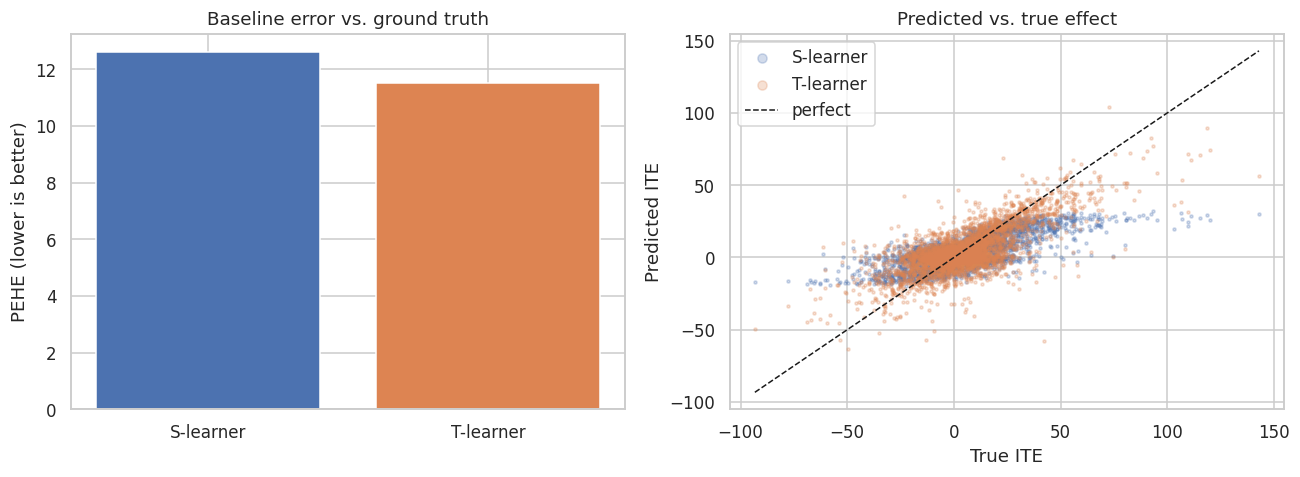

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(["S-learner", "T-learner"], [s_pehe, t_pehe], color=["#4C72B0", "#DD8452"])
axes[0].set_ylabel("PEHE (lower is better)")
axes[0].set_title("Baseline error vs. ground truth")

for name, pred in [("S-learner", s_pred_ite), ("T-learner", t_pred_ite)]:
    axes[1].scatter(test_df["ite_true"], pred, s=4, alpha=0.25, label=name)
lims = [test_df["ite_true"].min(), test_df["ite_true"].max()]
axes[1].plot(lims, lims, "k--", linewidth=1, label="perfect")
axes[1].set_xlabel("True ITE")
axes[1].set_ylabel("Predicted ITE")
axes[1].set_title("Predicted vs. true effect")
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.savefig("../figures/04_naive_baseline.png", bbox_inches="tight")
plt.show()

Both baselines systematically compress the effect estimates toward the
middle -- big persuadable effects get underestimated, and (more
importantly for a promo budget) sleeping-dog effects often don't even
come out negative. Neither model was ever told to correct for *why*
someone got the promo, only what happened after.

That's the gap the Day 2 model closes: a shared-representation neural
network with a propensity head (for IPW / doubly-robust correction) and
a self-attention block over the feature embeddings, evaluated against
these exact baselines.

In [5]:
import json
baseline_results = {"s_learner_pehe": s_pehe, "t_learner_pehe": t_pehe}
with open("../data/baseline_results.json", "w") as f:
    json.dump(baseline_results, f, indent=2)
baseline_results

{'s_learner_pehe': 12.620475580102026, 't_learner_pehe': 11.517443420962572}